**TAREA 1**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

**CASO 1: Tablero de ajedrez sin el uso de IA ni OpenCV.**

(800, 800, 1)


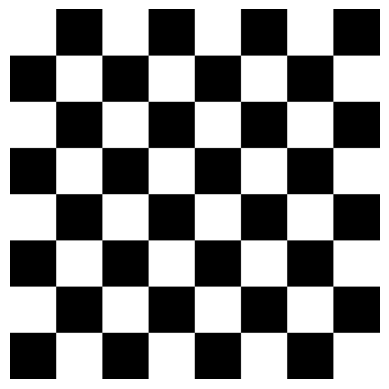

In [ ]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt


#Dimensiones de los tableros que vamos a crear
ancho = alto = 800
#Creamos nuestro primer tablero
tablero_ajedrez = np.zeros((alto,ancho,1), dtype = np.uint8)
print(tablero_ajedrez.shape)

#El tablero de ajedrez es un 8x8 por lo que es necesario saber cuál será el tamaño de nuestras cuadrículas
tamaño_cuadrícula = ancho // 8

for i in range(0, alto, tamaño_cuadrícula):
    fila_actual = i//tamaño_cuadrícula
    for j in range(0, ancho, 2*tamaño_cuadrícula):
        if (fila_actual) % 2 != 0:
            j += tamaño_cuadrícula
        tablero_ajedrez[i:i+tamaño_cuadrícula,j:j+tamaño_cuadrícula,0] = 255

#Muestra la imagen con matplotlib
plt.imshow(tablero_ajedrez, cmap='gray',vmin=0, vmax=255)
plt.axis('off')
plt.show()

**CASO 2: Tablero de ajedrez haciendo uso de OpenCV y sin uso de IA.**

In [ ]:
#Se crea un nuevo tablero
tablero_ajedrez_opencv = np.zeros((alto,ancho,1), dtype = np.uint8)
print(tablero_ajedrez_opencv.shape)

for i in range(0,alto, tamaño_cuadrícula):
    for j in range(0, ancho, 2*tamaño_cuadrícula):
        if (i//tamaño_cuadrícula) % 2 != 0:
            j+=tamaño_cuadrícula
        cv2.rectangle(tablero_ajedrez_opencv,(i,j),(i+tamaño_cuadrícula,j+tamaño_cuadrícula), 255, -1)

#Muestra la imagen con OpenCV
cv2.imshow("Tablero ajedrez con OpenCV", tablero_ajedrez_opencv)
cv2.waitKey(0)
cv2.destroyAllWindows()

(800, 800, 1)


**CASO 3: Tablero de ajedrez realizado por al IA**

In [ ]:
import cv2
import numpy as np

def dibujar_tablero(tamano_px, num_casillas=8,
                     color1=(255, 255, 255), color2=(0, 0, 0)):
    """
    Dibuja un tablero de ajedrez cuadrado.

    Parámetros:
        tamano_px (int): tamaño total del tablero en píxeles (alto = ancho).
        num_casillas (int): número de casillas por lado (por defecto 8, como el ajedrez real).
        color1 (tuple): color BGR de las casillas "claras".
        color2 (tuple): color BGR de las casillas "oscuras".

    Retorna:
        tablero (np.ndarray): imagen del tablero en formato BGR.
    """
    tablero = np.zeros((tamano_px, tamano_px, 3), dtype=np.uint8)

    # Tamaño de cada casilla (puede no ser un número entero exacto de píxeles,
    # por eso calculamos los bordes con round() para repartir bien el sobrante)
    tam_casilla = tamano_px / num_casillas

    for fila in range(num_casillas):
        for col in range(num_casillas):
            # Coordenadas de la casilla actual
            x1 = int(round(col * tam_casilla))
            x2 = int(round((col + 1) * tam_casilla))
            y1 = int(round(fila * tam_casilla))
            y2 = int(round((fila + 1) * tam_casilla))

            # Alternamos color según la paridad de fila+columna
            color = color1 if (fila + col) % 2 == 0 else color2

            cv2.rectangle(tablero, (x1, y1), (x2, y2), color, thickness=-1)

    return tablero


if __name__ == "__main__":
    # Ejemplos de uso con distintos tamaños
    tablero_1 = dibujar_tablero(tamano_px=400, num_casillas=8)
    tablero_2 = dibujar_tablero(tamano_px=640, num_casillas=4)
    tablero_3 = dibujar_tablero(tamano_px=800, num_casillas=16,
                                 color1=(200, 200, 255), color2=(50, 0, 100))

    cv2.imshow("Tablero 8x8 - 400px", tablero_1)
    cv2.imshow("Tablero 4x4 - 640px", tablero_2)
    cv2.imshow("Tablero 16x16 - 800px", tablero_3)

    cv2.waitKey(0)
    cv2.destroyAllWindows()

Entre las tres diferentes versiones podemos observar cómo la versión realizada sin OpenCV y la que usa OpenCV se ve de igual manera, siendo el único cambio la manera en la que se construyen los cuadros y como se muestra, posteriormente, el tablero creado. En la primera, esto se realiza pintando los píxeles, mientras que en la versión con OpenCV se pintan los cuadros directamente. Respecto a la versión realizada por IA, se ha realizado usando Claude con el siguiente prompt: 'dame un codigo de python que use la librería opencv para dibujar un tablero de ajedrez independientemente del tamaño dado de trablero. el alto y ancho siempre será el mismo'.

Como se puede observar en la versión de la IA esta ha estructurado el código de la creación del trablero como una función que se usa posteriormente en el código. Además, ha generado dicha función dando la posibilidad de elegir el tamaño, el numero de casillas y el color de las mismas en la llamada.

**TAREA 2**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

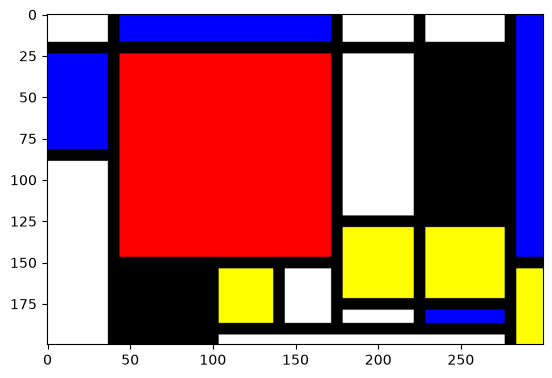

True

In [4]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

#Creación del marco
alto = 200
ancho = 300
color_img = np.zeros((alto,ancho,3), dtype = np.uint8)
color_img = np.zeros((alto,ancho,3), dtype = np.uint8)

#Rectángulos de los diferentes colores
cv2.rectangle(color_img,(0,0),(49,20),(255,255,255),-1)
cv2.rectangle(color_img,(44,0),(174,20),(0,0,255),-1)
cv2.rectangle(color_img,(176,0),(280,20),(255,255,255),-1)
cv2.rectangle(color_img,(280,0),(300,150),(0,0,255),-1)
cv2.rectangle(color_img,(280,150),(300,200),(255,255,0),-1)
cv2.rectangle(color_img,(100,190),(280,200),(255,255,255),-1)
cv2.rectangle(color_img,(40,150),(100,200),(0,0,0),-1)
cv2.rectangle(color_img,(40,150),(100,200),(0,0,0),-1)
cv2.rectangle(color_img,(0,85),(40,200),(255,255,255),-1)
cv2.rectangle(color_img,(0,21),(40,84),(0,0,255),-1)
cv2.rectangle(color_img,(41,21),(175,150),(255,0,0),-1)
cv2.rectangle(color_img,(101,151),(140,189),(255,255,0),-1)
cv2.rectangle(color_img,(141,151),(175,189),(255,255,255),-1)
cv2.rectangle(color_img,(141,151),(175,189),(255,255,255),-1)
cv2.rectangle(color_img,(176,21),(225,125),(255,255,255),-1)
cv2.rectangle(color_img,(226,21),(279,125),(0,0,0),-1)
cv2.rectangle(color_img,(176,126),(279,174),(255,255,0),-1)
cv2.rectangle(color_img,(176,175),(225,189),(255,255,255),-1)
cv2.rectangle(color_img,(226,175),(279,189),(0,0,255),-1)

#Líneas para la división de los rectángulos
cv2.line(color_img,(40,0),(40,200),(0,0,0),5)
cv2.line(color_img,(100,150),(100,200),(0,0,0),5)
cv2.line(color_img,(140,150),(140,190),(0,0,0),5)
cv2.line(color_img,(175,0),(175,190),(0,0,0),5)
cv2.line(color_img,(225,0),(225,190),(0,0,0),5)
cv2.line(color_img,(280,0),(280,200),(0,0,0),5)
cv2.line(color_img,(0,20),(280,20),(0,0,0),5)
cv2.line(color_img,(0,85),(40,85),(0,0,0),5)
cv2.line(color_img,(40,150),(175,150),(0,0,0),5)
cv2.line(color_img,(100,190),(280,190),(0,0,0),5)
cv2.line(color_img,(175,125),(280,125),(0,0,0),5)
cv2.line(color_img,(175,175),(280,175),(0,0,0),5)
cv2.line(color_img,(280,150),(300,150),(0,0,0),5)

#Visualiza sin especificar el mapa de color gris
plt.imshow(color_img) 
plt.show()

#Convertimos a BGR, manejo de colores nativo de OpenCV, para guardar la imagen sin colores invertidos
color_img = cv2.cvtColor(color_img, cv2.COLOR_RGB2BGR)

#Salva la imagen resultante a disco
cv2.imwrite('imagen1.jpg', color_img)

(900, 800, 3)


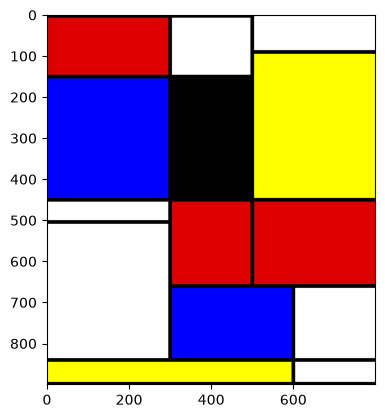

True

In [5]:
#Crea una imagen con tres planos
alto=900
ancho=800

#Crea una imagen con tres planos
color_img = np.zeros((alto,ancho,3), dtype = np.uint8)
print(color_img.shape)

#Establecer la imagen inicial completamente blanca
color_img[:,:,:] = 255

#Línea roja vertical de grosor 3
cv2.line(color_img,(int((ancho/8)*5),0),(int((ancho/8)*5),int((alto*11)/15)),(0,0,0),8)
cv2.line(color_img,(int((ancho/8)*3),0),(int((ancho/8)*3),int((alto*14)/15)),(0,0,0),8)

#Rectángulos rojos
cv2.rectangle(color_img,(0,0),(int((ancho/8)*3)-5,int(alto/6)-5),(220,0,0),-1)
cv2.rectangle(color_img,(int((ancho/8)*3)+5,int(alto/2)),(int((ancho/8)*5)-5,int((alto*11)/15)),(220,0,0),-1)
cv2.rectangle(color_img,(int((ancho/8)*5)+5,int(alto/2)),(ancho,int((alto*11)/15)),(220,0,0),-1)


cv2.line(color_img,(0,0),(int((ancho/8)*5), 0),(0,0,0),12)
cv2.line(color_img,(0,int(alto/6)),(int((ancho/8)*5), int(alto/6)),(0,0,0),8)

cv2.line(color_img,(int((ancho/8)*5),int(alto/10)),(ancho, int(alto/10)),(0,0,0),8)

cv2.rectangle(color_img,(int((ancho/8)*3),int(alto/6)),(int((ancho/8)*5),int(alto/2)),(0,0,0),-1)

#Rectángulos azules
cv2.rectangle(color_img,(0,int(alto/6)+5),(int((ancho/8)*3)-5,int(alto/2)),(0,0,255),-1)
cv2.rectangle(color_img,(int((ancho/8)*3)+5,int((alto*11)/15)+5),(int((ancho/8)*6)-5,int((alto*14)/15)-5),(0,0,255),-1)

cv2.line(color_img,(0,int(alto/2)),(ancho, int(alto/2)),(0,0,0),8)
cv2.line(color_img,(0,int(alto/16)*9),(int((ancho/8)*3), int(alto/16)*9),(0,0,0),8)

cv2.line(color_img,(int((ancho/8)*3) ,int((alto*11)/15)),(ancho, int((alto*11)/15)),(0,0,0),8)
cv2.line(color_img,(int((ancho/8)*6) ,int((alto*11)/15)),(int((ancho/8)*6), alto),(0,0,0),8)
cv2.line(color_img,(0,int((alto*14)/15)),(ancho, int((alto*14)/15)),(0,0,0),8)

#Rectangulos amarillos
cv2.rectangle(color_img, (int((ancho/8)*5)+5,int(alto/10)+5), (ancho, int(alto/2)-5), (255,255,0), -1)
cv2.rectangle(color_img, (0,int((alto*14)/15)+5), (int((ancho/8)*6)-5, alto), (255,255,0), -1)

cv2.line(color_img,(0,alto),(ancho, alto),(0,0,0),12)

#Visualiza sin especificar el mapa de color gris
plt.imshow(color_img) 
plt.show()

#Convertimos a BGR, manejo de colores nativo de OpenCV, para guardar la imagen sin colores invertidos
color_img = cv2.cvtColor(color_img, cv2.COLOR_RGB2BGR)

#Salva la imagen resultante a disco
cv2.imwrite('imagen.jpg', color_img)

Se pueden ver los resultados de las dos versiones diferentes de cuadros Mondrian realizados con OpenCV, utilizando rectángulos y líneas. En uno de ellos se hace uso de coordenadas absolutas dentro del lienzo, mientras que en la segunda propuesta se usan coordenadas relativas al lienzo.

**TAREA 3**: Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.

In [1]:
import cv2

def bright_dark_px(frame):
    gray_frame = cv2.medianBlur(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), 5)
    min_val, max_val, min_px, max_px = cv2.minMaxLoc(gray_frame)
    return min_px, max_px

video = cv2.VideoCapture(0)

if video.isOpened:
    while True:
        ret, frame = video.read()

        min_px, max_px = bright_dark_px(frame)
        cv2.circle(frame, min_px, 5, (0,0,255), -1)
        cv2.circle(frame, max_px, 5, (0,255,0), -1)

        if ret:
            cv2.imshow('Video', frame)

        if cv2.waitKey(20) == 27:
            break

    video.release()
    cv2.destroyAllWindows()

Se ha conseguido que los puntos se muevan de una manera fluida aunque genera saltos al cambiar los puntos de mayor o menor luminosidad. Se ha utilizado un punto rojo para representar el punto más oscuro y un punto verde para representar el más claro. Se adjunta debajo la conversación con la IA para conocer que funciones nos aporta la librería para poder localizar nuestros puntos de interés.

Conversación con IA: https://claude.ai/share/3b2a8385-3039-41a8-8244-3716657d239e

**TAREA 4**: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [ ]:
import cv2
import numpy as np
import time

vid = cv2.VideoCapture(0)

#Función para cambiar los colores
def color_random():
    color = np.random.uniform(0.0, 1.0, 3)
    return color / color.max()

azul  = np.array([1.0, 0.3, 0.0])
verde = np.array([0.0, 1.0, 0.3])
rojo  = np.array([0.0, 0.3, 1.0])
ultimo_cambio = time.time()

while True:
    ret, frame = vid.read()

    if ret:
        alto, ancho, canales = frame.shape

        #Comprobación de si debemos cambiar el color
        if (time.time() - ultimo_cambio) > 1.5:
            azul, verde, rojo = color_random(), color_random(), color_random()
            ultimo_cambio = time.time()
        
        b = frame[:, :, 0].astype(np.float32)
        g = frame[:, :, 1].astype(np.float32)
        r = frame[:, :, 2].astype(np.float32)

        #Cambio los colores
        b_color = np.clip(b[:, :, None] * azul,  0, 255).astype(np.uint8)
        g_color = np.clip(g[:, :, None] * verde, 0, 255).astype(np.uint8)
        r_color = np.clip(r[:, :, None] * rojo,  0, 255).astype(np.uint8)


        #Agrupamiento de los frames en filas
        fila1 = np.hstack((r_color, g_color))
        fila2 = np.hstack((b_color, frame))

        #Agrupamiento de las filas en columnas
        collage = np.vstack((fila1, fila2))

        cv2.imshow('RGB 2x2', cv2.resize(collage, (ancho, alto), interpolation=cv2.INTER_NEAREST))

    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

Como propuesta para el pop art hemos decidido dividir la cámara en 4 frames que van cambiando de color cada 1.5 s, dejando uno de los 4 frames como el frame original, para que se vea el cambio respecto a los otros.
Conversación con la IA: https://claude.ai/share/20114d8a-dbee-4d59-a757-e3b33c6fa411